<a href="https://colab.research.google.com/github/ligafinancefiap-svg/core-finance-lib/blob/main/00_Data_Lake_Consolidacao_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ele é o "Cérebro" que lê apenas os arquivos que estão na sua camada 03_Gold.

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


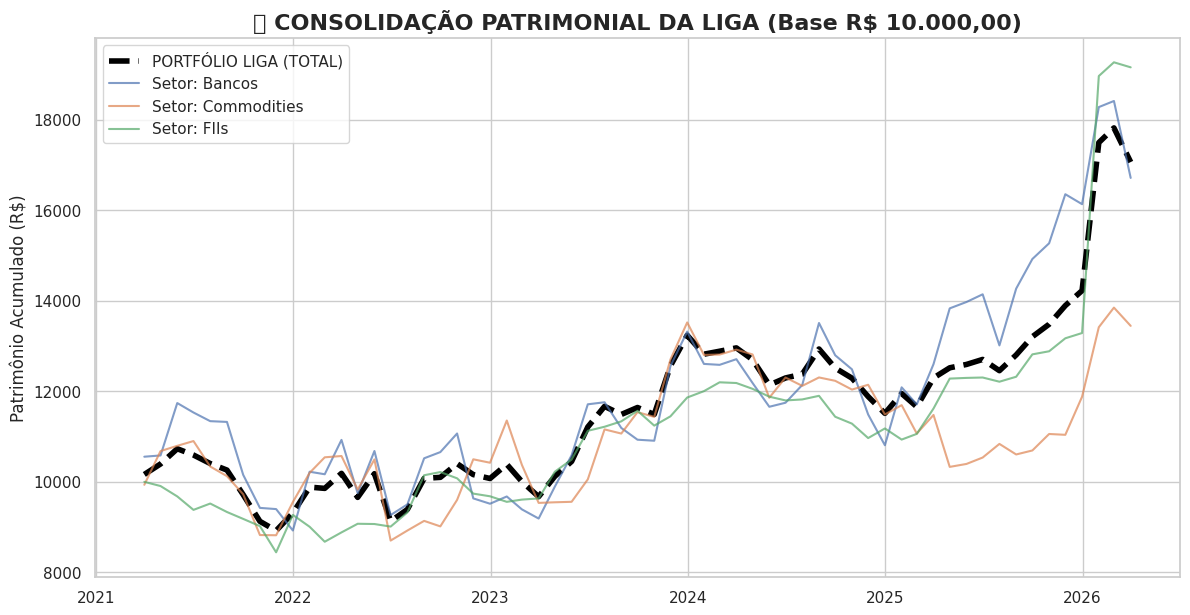


🏆 PERFORMANCE ACUMULADA POR SETOR:
Bancos         67.10%
Commodities    34.42%
FIIs           91.53%
LIGA_TOTAL     70.60%
Name: 2026-03-31 00:00:00, dtype: object


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Conexão
drive.mount('/content/drive')
caminho_gold = '/content/drive/MyDrive/DATA_LAKE/03_Gold/'

def carregar_dados_gold():
    # Lendo os retornos mensais que salvamos na Camada Gold
    bancos = pd.read_csv(f'{caminho_gold}b3_bancos_retorno_mensal.csv', index_col=0, parse_dates=True)
    commo = pd.read_csv(f'{caminho_gold}b3_commodities_retorno_mensal.csv', index_col=0, parse_dates=True)
    fiis = pd.read_csv(f'{caminho_gold}b3_fiis_retorno_mensal.csv', index_col=0, parse_dates=True)

    # Criando a média de retorno de cada setor (Considerando pesos iguais)
    portfolio = pd.DataFrame({
        'Bancos': bancos.mean(axis=1),
        'Commodities': commo.mean(axis=1),
        'FIIs': fiis.mean(axis=1)
    })
    return portfolio

# 2. Processamento do Portfólio Consolidado
df_port = carregar_dados_gold()

# Calculando o Retorno Total do Portfólio da Liga (Média dos 3 setores)
df_port['LIGA_TOTAL'] = df_port.mean(axis=1)

# Transformando retornos em evolução patrimonial (Base R$ 10.000)
df_evolucao = (1 + df_port).cumprod() * 10000

# 3. Visualização de Dono da Gestora
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Plotando a linha principal (O valor total da Liga)
plt.plot(df_evolucao.index, df_evolucao['LIGA_TOTAL'], label='PORTFÓLIO LIGA (TOTAL)', color='black', linewidth=4, linestyle='--')

# Plotando os setores para comparação
for coluna in ['Bancos', 'Commodities', 'FIIs']:
    plt.plot(df_evolucao.index, df_evolucao[coluna], label=f'Setor: {coluna}', alpha=0.7)

plt.title("📈 CONSOLIDAÇÃO PATRIMONIAL DA LIGA (Base R$ 10.000,00)", fontsize=16, fontweight='bold')
plt.ylabel("Patrimônio Acumulado (R$)")
plt.legend()
plt.show()

# Relatório Final de Fechamento
print("\n🏆 PERFORMANCE ACUMULADA POR SETOR:")
print(((df_evolucao.iloc[-1] / 10000 - 1) * 100).round(2).map("{:.2f}%".format))